In [5]:
# Install required packages for this notebook
%pip install scipy numpy pandas matplotlib ipykernel

Note: you may need to restart the kernel to use updated packages.


In [1]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset (Example using RW9 from the Uniform Distribution Charge/Discharge subset)
file_path = r'1. Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post\Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post\data\Matlab\RW9.mat'
mat = scipy.io.loadmat(file_path)

# Extract Battery Info for plots
path_parts = file_path.replace('/', '\\').split('\\')
# Extract informative part from parent folders 
folder_name = path_parts[-4] if len(path_parts) >= 4 else ""
if '. ' in folder_name:
    folder_name = folder_name.split('. ', 1)[1]
battery_name = path_parts[-1].replace('.mat', '')
battery_title = f"{folder_name} - {battery_name}" if folder_name else battery_name

# Validate Data Load
print(f"Loaded Battery Data: {battery_title}")

Loaded Battery Data: Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post - RW9


--- RANDOM WALK LIFECYCLE SUMMARY ---
Total Cumulative Charge: 1831.96 Ah
Total Cumulative Discharge: 1894.96 Ah
Total Active Steps Processed: 48201


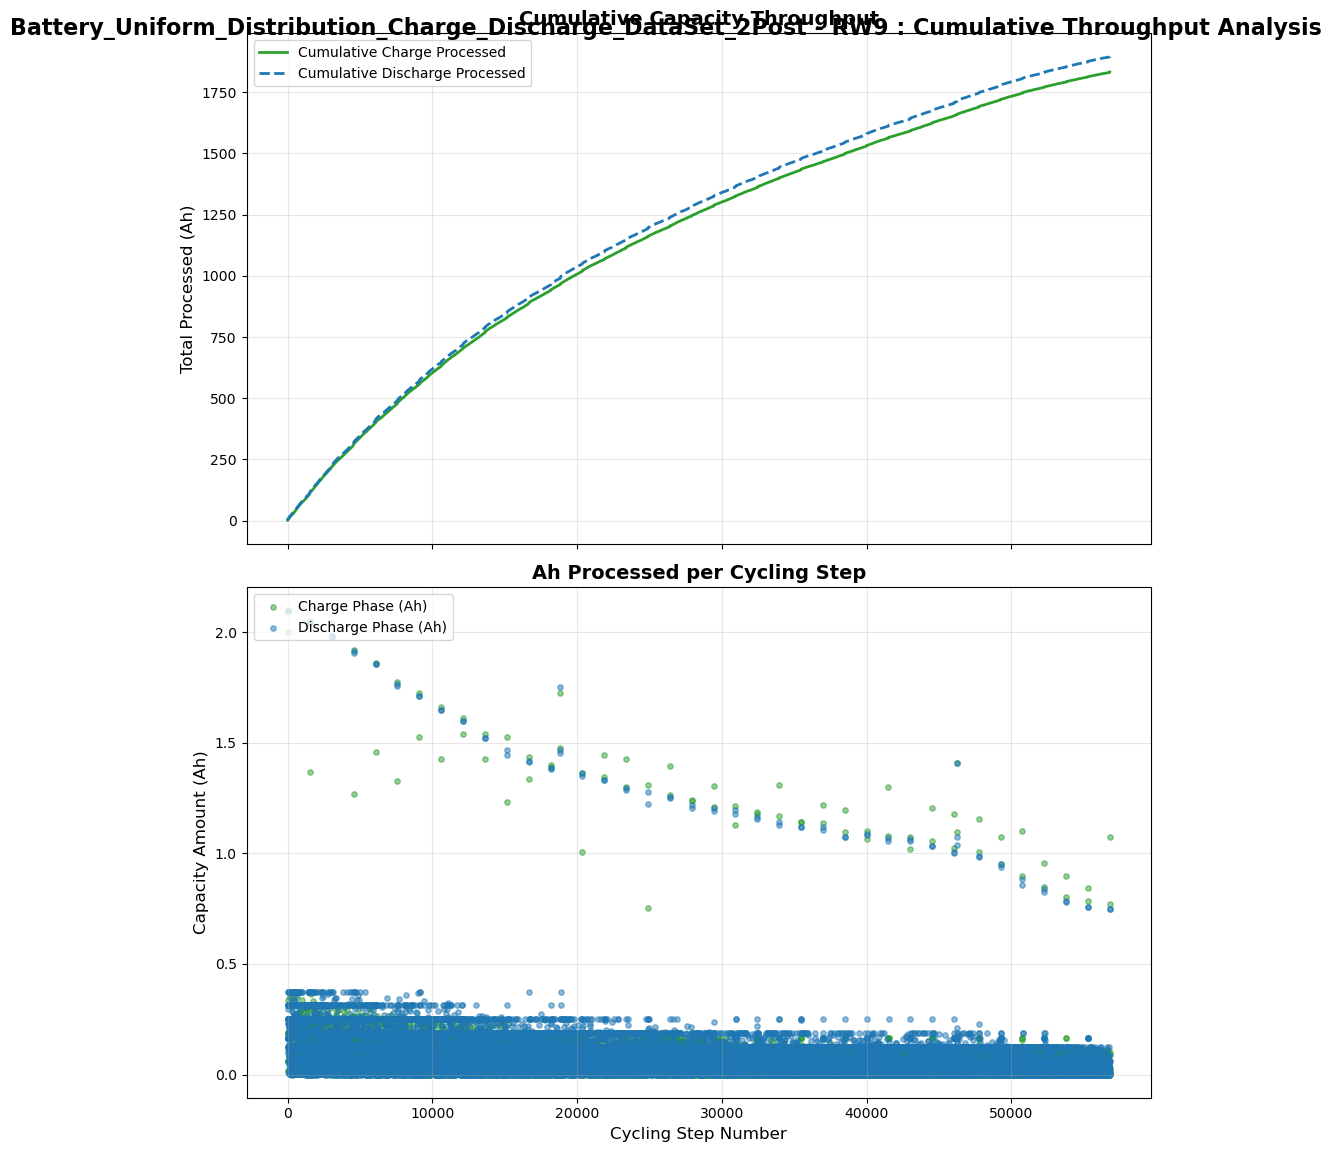

In [9]:
# Process Data Structure for Random Walk Experiments
data_struct = mat['data'][0, 0]
steps = data_struct['step'][0]

results = []
total_charge_ah = 0.0
total_discharge_ah = 0.0

cycle_count = 1

# Iterate through every cycling step (Charging, Discharging, or Resting)
for step in steps:
    s_type = step['type'][0] if len(step['type']) > 0 else ''
    comment = step['comment'][0] if len(step['comment']) > 0 else ''
    
    # Process only Charge or Discharge modes
    if s_type in ['C', 'D']:
        # Older structs used "relativeTime", some newer datasets use "time". 
        # "time" handles timestamps globally across the experiment.
        time = step['time'][0] if 'time' in step.dtype.names else step['relativeTime'][0]
        current = step['current'][0]
        voltage = step['voltage'][0]
        
        # Guard clause against empty logs
        if len(time) > 1:
            dt = np.diff(time.flatten())
            curr_flat = current.flatten()
            
            # Simple numerical integration using Trapz method
            avg_current = (np.abs(curr_flat[:-1]) + np.abs(curr_flat[1:])) / 2
            ah_processed = np.sum(avg_current * dt) / 3600
            
            if s_type == 'C':
                total_charge_ah += ah_processed
                results.append({'Step': cycle_count, 'Type': 'Charge', 'Ah': ah_processed, 
                                'Cum_Charge': total_charge_ah, 'Cum_Discharge': total_discharge_ah,
                                'Comment': comment})
            elif s_type == 'D':
                total_discharge_ah += ah_processed
                results.append({'Step': cycle_count, 'Type': 'Discharge', 'Ah': ah_processed, 
                                'Cum_Charge': total_charge_ah, 'Cum_Discharge': total_discharge_ah,
                                'Comment': comment})
                
        cycle_count += 1

df = pd.DataFrame(results)

if len(df) > 0:
    print(f"--- RANDOM WALK LIFECYCLE SUMMARY ---")
    print(f"Total Cumulative Charge: {total_charge_ah:.2f} Ah")
    print(f"Total Cumulative Discharge: {total_discharge_ah:.2f} Ah")
    print(f"Total Active Steps Processed: {len(df)}")
    
    fig, axs = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
    fig.suptitle(f"{battery_title} : Cumulative Throughput Analysis", fontsize=16, fontweight='bold', y=0.95)

    # Plot 1: Cumulative Capacity Throughput
    axs[0].plot(df['Step'], df['Cum_Charge'], label='Cumulative Charge Processed', color='tab:green', linewidth=2)
    axs[0].plot(df['Step'], df['Cum_Discharge'], label='Cumulative Discharge Processed', color='tab:blue', linestyle='--', linewidth=2)
    axs[0].set_title('Cumulative Capacity Throughput', fontsize=14, fontweight='bold')
    axs[0].set_ylabel('Total Processed (Ah)', fontsize=12)
    axs[0].legend(loc='upper left')
    axs[0].grid(True, alpha=0.3)
    
    # Plot 2: Scatter of individual step capacities
    df_charge = df[df['Type'] == 'Charge']
    df_discharge = df[df['Type'] == 'Discharge']
    axs[1].scatter(df_charge['Step'], df_charge['Ah'], label='Charge Phase (Ah)', color='tab:green', alpha=0.5, s=15)
    axs[1].scatter(df_discharge['Step'], df_discharge['Ah'], label='Discharge Phase (Ah)', color='tab:blue', alpha=0.5, s=15)
    axs[1].set_title('Ah Processed per Cycling Step', fontsize=14, fontweight='bold')
    axs[1].set_xlabel('Cycling Step Number', fontsize=12)
    axs[1].set_ylabel('Capacity Amount (Ah)', fontsize=12)
    axs[1].legend(loc='upper left')
    axs[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid charge/discharge steps found.")

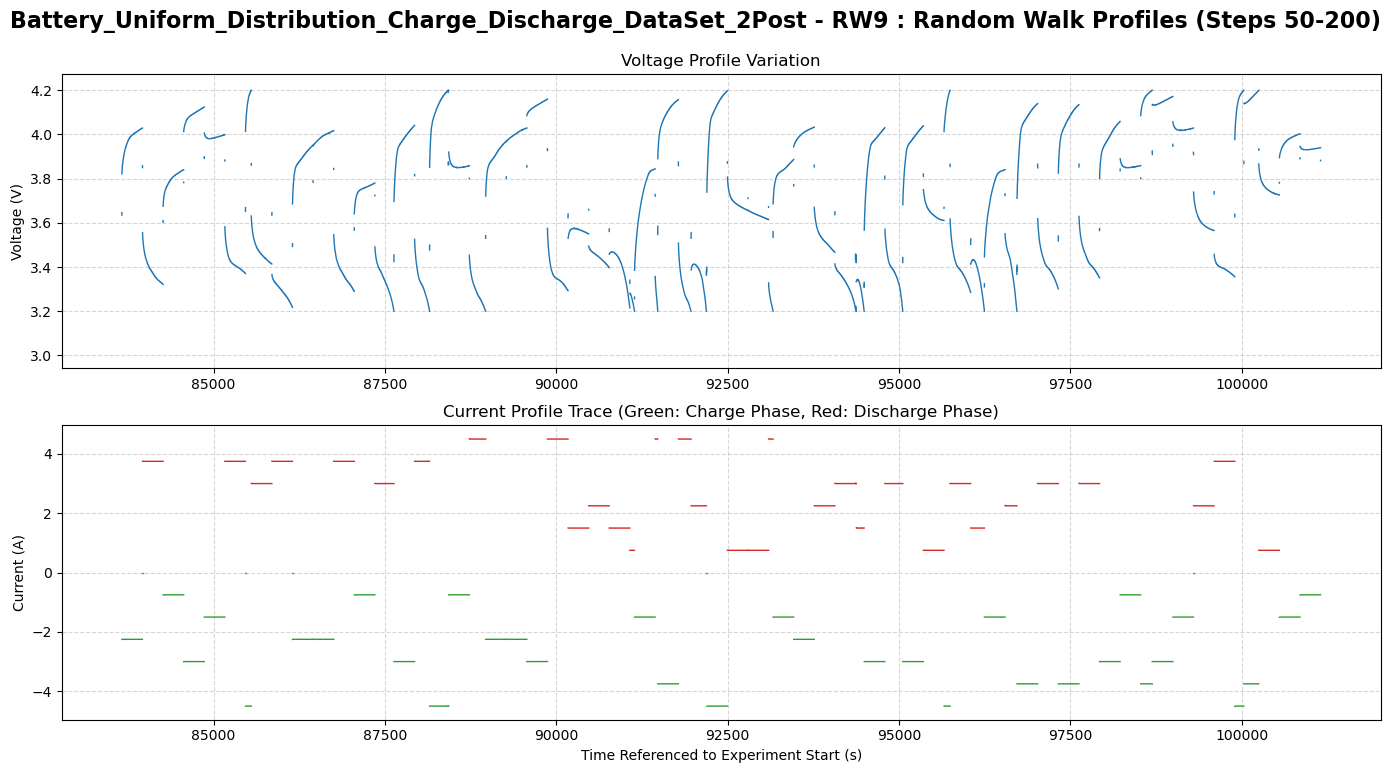

In [10]:
try:
    # Zoom in to a window of randomized steps to observe the signal profile
    # The whole experiment has tens of thousands of steps, so we visualize a smaller subset.
    window_start = 50
    window_end = min(200, len(steps))
    
    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(f"{battery_title} : Random Walk Profiles (Steps {window_start}-{window_end})", fontsize=16, fontweight='bold', y=0.96)
    
    ax1 = plt.subplot(2, 1, 1)
    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    
    for i in range(window_start, window_end):
        time = steps[i]['time'][0].flatten()
        voltage = steps[i]['voltage'][0].flatten()
        current = steps[i]['current'][0].flatten()
        s_type = steps[i]['type'][0] if len(steps[i]['type']) > 0 else ''
        
        if len(time) > 0:
             # Legend mapping colors relative to operation type
             c = 'tab:green' if s_type == 'C' else ('tab:red' if s_type == 'D' else 'tab:gray')
             
             ax1.plot(time, voltage, color='tab:blue', linewidth=1)
             ax2.plot(time, current, color=c, linewidth=1)

    ax1.set_title("Voltage Profile Variation")
    ax1.set_ylabel("Voltage (V)")
    ax1.grid(True, alpha=0.5, linestyle='--')
    
    ax2.set_title("Current Profile Trace (Green: Charge Phase, Red: Discharge Phase)")
    ax2.set_ylabel("Current (A)")
    ax2.set_xlabel("Time Referenced to Experiment Start (s)")
    ax2.grid(True, alpha=0.5, linestyle='--')
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.88)
    plt.show()
except Exception as e:
    print(f"Error generating profile plot: {e}")
